# Valid Frames

This notebook checks the valid frames for responses and videos across recordings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from utils.dataset import DataSet

Define the paths used to access data and metadata.

In [2]:
# data folder
folder_data = repo_root / 'data'

# metadata folder
folder_meta = repo_root / 'metadata'

# mice/recording folders
all_recording_folders = [
    'dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29623-4-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20',
]

Initialize a `DataSet` object to handle the full dataset.

In [3]:
# Inizialize and object from DataSet to handle the dataset
ds = DataSet(folder_data, 
             folder_metadata=folder_meta,
             recording=all_recording_folders, 
             check=False,
             verbose=True)

# Load the metadat for all triasls
trials_df = ds.get_trials_metadata()

# Mapping from recording name to rec-animalID-session-scan format
mapping = {}
for rec in ds.recording:
    x = rec.split("-")
    mapping[rec] = f"rec-{ds.info[rec]['animal_id']}-{ds.info[rec]['session']}-{ds.info[rec]['scan_idx']}"



Initializing DataSet -------------------------------------------------------------------------------

Data integrity check skipped -----------------------------------------------------------------------
 > If you want to check it, set check and check_data to True when initializing the DataSet.
 > Data is assumed to be valid. Misbehavior may occur if the data is corrupted.

Metadata integrity check skipped -------------------------------------------------------------------
 > If you want to check it, set check and check_metadata to True when initializing the DataSet.
 > Metadata will be assumed to be valid for existing folders and invalid for missing folders.

Loading neurons metadata ---------------------------------------------------------------------------
 > Loading neurons for recording dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce from metadata
 > Loading neurons for recording dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce from metadata
 > Loading neurons fo

## Differences in valid frames

See how many trials there are per recording with a different number of valid frames between the video and the response

In [ ]:
trials_df["valid_frames_diff"] = trials_df["valid_frames_video"] - trials_df["valid_frames_response"]
result = (
    trials_df.groupby("recording")["valid_frames_diff"]
    .apply(lambda x: {
        "video>response": (x > 0).sum(),
        "response>video": (x < 0).sum(),
        "equal":     (x == 0).sum()
    })
    .apply(pd.Series)
    .reset_index()
)
result.columns = ["recording", "relation", "count"]
result


,recording,relation,count
0,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,video>response,0
1,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,response>video,0
2,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,equal,720
3,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,video>response,0
4,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,response>video,0
5,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,equal,704
6,dynamic29234-6-9-Video-8744edeac3b4d1ce16b6809...,video>response,0
7,dynamic29234-6-9-Video-8744edeac3b4d1ce16b6809...,response>video,0
8,dynamic29234-6-9-Video-8744edeac3b4d1ce16b6809...,equal,729
9,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,video>response,0


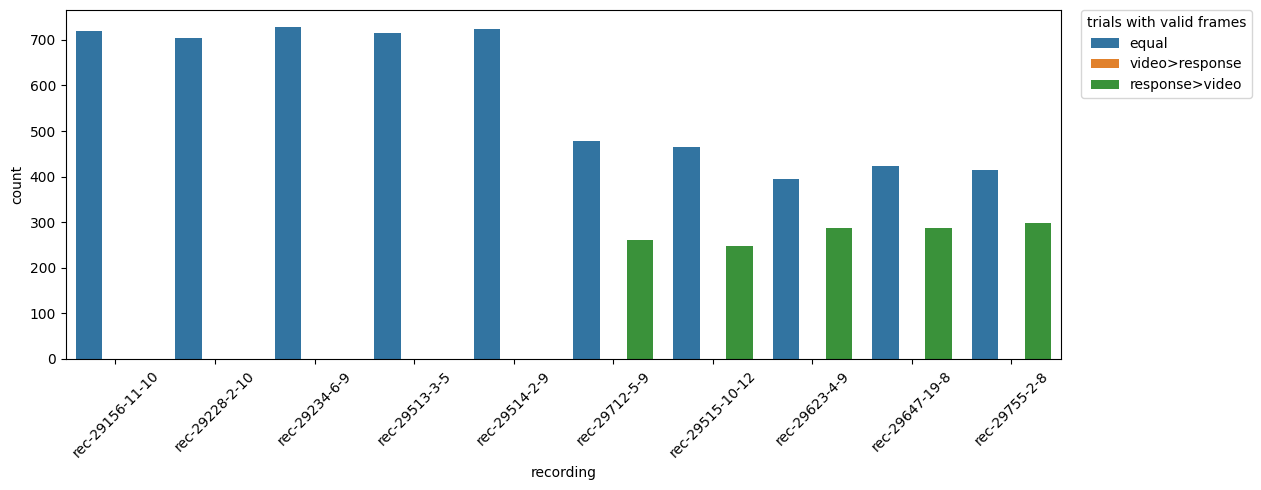

In [ ]:
result["recording_short_label"] = result["recording"].map(mapping)
rec_order = [mapping[rec] for rec in all_recording_folders]

fig, ax = plt.subplots(figsize=(15, 5))
sns.barplot(data=result, x="recording_short_label", y="count", hue="relation", order=rec_order, hue_order=["equal","video>response","response>video"], ax=ax)
ax.tick_params(axis='x', rotation=45)
ax.set_xlabel("recording")
ax.legend(
    title="valid frames in video and response",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)
fig.tight_layout(rect=[0, 0, 0.85, 1])
#fig.savefig(Path(repo_root, 'figures', f"valid-frames_x-recording.png"), dpi=300)
plt.show()


In [12]:
min_diff = np.min(trials_df["valid_frames_diff"].to_numpy())
max_diff = np.max(trials_df["valid_frames_diff"].to_numpy())
print(f"range for valid_frames_diff [{min_diff}, {max_diff}]")

range for valid_frames_diff [-114, 0]


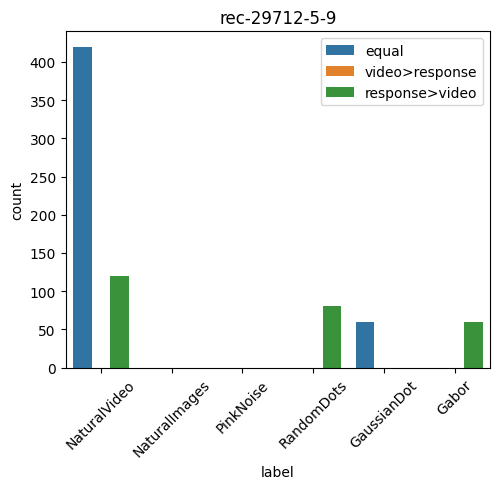

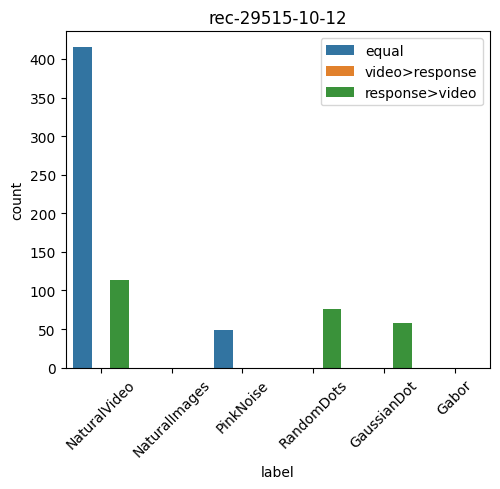

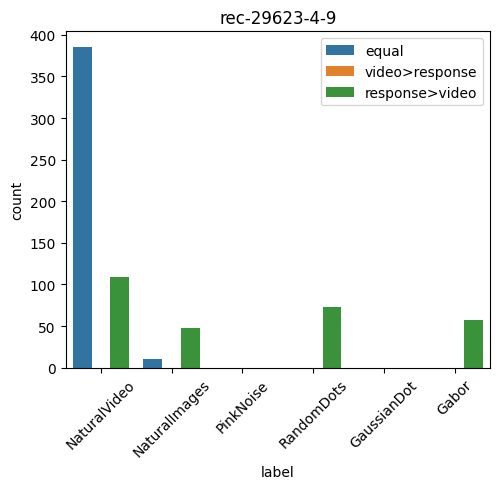

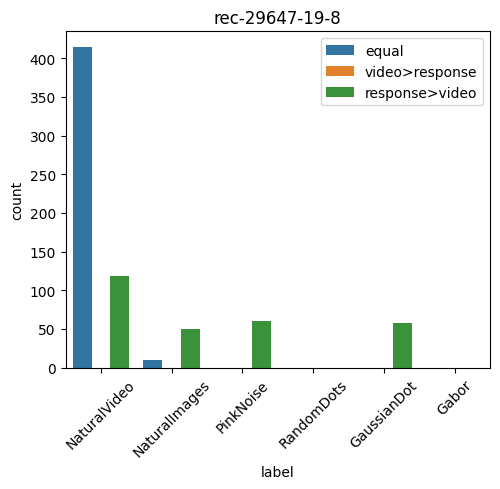

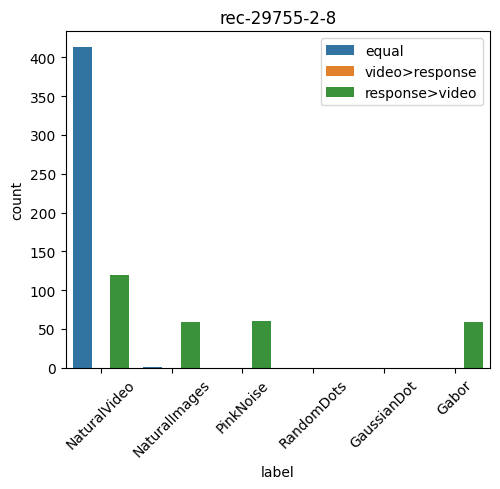

In [34]:
labels_order=["NaturalVideo", "NaturalImages", "PinkNoise","RandomDots","GaussianDot","Gabor"]
for rec in ds.recording:
    df = trials_df[trials_df['recording']==rec]
    if any(df["valid_frames_diff"]!=0):
        result_rec = (
        df.groupby("label")["valid_frames_diff"]
        .apply(lambda x: {
            "video>response": (x > 0).sum(),
            "response>video": (x < 0).sum(),
            "equal":     (x == 0).sum()
        })
        .apply(pd.Series)
        .reset_index()
        )
        result_rec.columns = ["label", "relation", "count"]

        fig, ax = plt.subplots(figsize=(6, 5))
        sns.barplot(data=result_rec, x="label", y="count", hue="relation", order=labels_order, hue_order=["equal","video>response","response>video"], ax=ax)
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel("label")
        ax.legend()
        ax.set_title(mapping[rec])
        fig.tight_layout(rect=[0, 0, 0.85, 1])
        #fig.savefig(Path(repo_root, 'figures', f"valid-frames_x-recording.png"), dpi=300)
        plt.show()

   
    